# 03 Residuals

This notebook extracts and analyzes VAR residuals from the fitted models.

The goal is to examine whether the residuals reveal innovation misspecification across the simulated DGPs.

This notebook motivates the innovation-modeling stage by showing when Gaussian residual assumptions are reasonable and when they fail.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from src.utils.seeds import set_seed
from src.utils.logging_utils import make_run_dir, save_metrics_json, save_table_csv
from src.data.loaders import load_npz, save_npz
from src.vector_ar.diagnostics import summarize_var_diagnostics

set_seed(123)

dgp_names = [
    "gaussian",
    "student_t",
    "mixture",
    "heteroskedastic",
]

model_dir = ROOT / "results" / "models" / "02_var_deepar_fit"
resid_dir = ROOT / "results" / "residuals" / "03_residuals"
table_dir = ROOT / "results" / "tables" / "03_residuals"

resid_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

residual_store = {}

for name in dgp_names:
    fit_path = model_dir / f"{name}_var_fit.npz"
    fit_data = load_npz(fit_path)

    residuals = fit_data["residuals"]

    residual_store[name] = residuals

    print(name, residuals.shape)

gaussian (299, 3)
student_t (299, 3)
mixture (299, 3)
heteroskedastic (299, 3)


In [8]:
# save residuals seperately
for name, residuals in residual_store.items():
    save_npz(
        resid_dir / f"{name}_var_residuals.npz",
        residuals=residuals,
    )

print("Saved residual files to:", resid_dir)

Saved residual files to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/residuals/03_residuals


In [2]:
rows = []

for name, residuals in residual_store.items():
    diag = summarize_var_diagnostics(residuals)
    k = residuals.shape[1]

    for j in range(k):
        rows.append({
            "dgp": name,
            "series": j + 1,
            "mean": diag["mean"][j],
            "std": diag["std"][j],
            "skewness": diag["skewness"][j],
            "kurtosis": diag["kurtosis"][j],
            "excess_kurtosis": diag["excess_kurtosis"][j],
            "jb_stat": diag["jarque_bera_stat"][j],
            "jb_pvalue": diag["jarque_bera_pvalue"][j],
            "autocorrelation_lag1": diag["autocorrelation_lag1"][j],
        })

residual_diagnostics_df = pd.DataFrame(rows)
residual_diagnostics_df

,dgp,series,mean,std,skewness,kurtosis,excess_kurtosis,jb_stat,jb_pvalue,autocorrelation_lag1
0,gaussian,1,-1.930823e-17,1.018841,-0.213540,3.365426,0.365426,3.684234,1.584815e-01,-0.009457
1,gaussian,2,-1.708035e-17,0.979803,0.245287,3.304344,0.304344,3.939902,1.394637e-01,-0.011695
2,gaussian,3,9.654113e-18,1.032848,0.041653,2.989496,-0.010504,0.097052,9.526328e-01,-0.014136
3,student_t,1,1.930823e-17,1.395511,0.329639,7.835382,4.835382,284.667627,1.531829e-62,0.002325
4,student_t,2,1.299592e-17,1.410934,0.295128,7.625325,4.625325,259.765879,3.913417e-57,-0.043033
5,student_t,3,2.246438e-16,1.350534,-1.269022,9.825909,6.825909,637.417498,3.859659e-139,-0.008899
6,mixture,1,-4.567138e-17,1.396293,0.127442,5.084904,2.084904,52.151057,4.737419e-12,-0.022242
7,mixture,2,-7.574766e-17,1.368537,-0.101312,6.905191,3.905191,182.321577,2.566685e-40,-0.015122
8,mixture,3,-1.203051e-16,1.483647,-0.195361,7.274322,4.274322,219.891066,1.783453e-48,-0.008401
9,heteroskedastic,1,-1.342293e-16,1.899822,-0.525117,5.594649,2.594649,93.440504,5.124509e-21,0.057354


In [3]:
summary_df = residual_diagnostics_df.groupby("dgp")[
    [
        "skewness",
        "kurtosis",
        "excess_kurtosis",
        "jb_pvalue",
        "autocorrelation_lag1",
    ]
].mean()

summary_df

,skewness,kurtosis,excess_kurtosis,jb_pvalue,autocorrelation_lag1
dgp,,,,,
gaussian,0.024466,3.219755,0.219755,4.168593e-01,-0.011763
heteroskedastic,-0.091313,5.683345,2.683345,6.997397e-20,0.012030
mixture,-0.056410,6.421472,3.421472,1.579140e-12,-0.015255
student_t,-0.214752,8.428872,5.428872,1.304477e-57,-0.016536


In [9]:
# save diagnostics
save_table_csv(
    residual_diagnostics_df,
    table_dir / "residual_diagnostics_by_series.csv",
)

save_table_csv(
    summary_df.reset_index(),
    table_dir / "residual_diagnostics_summary.csv",
)

print("Saved diagnostic tables to:", table_dir)

Saved diagnostic tables to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/tables/03_residuals


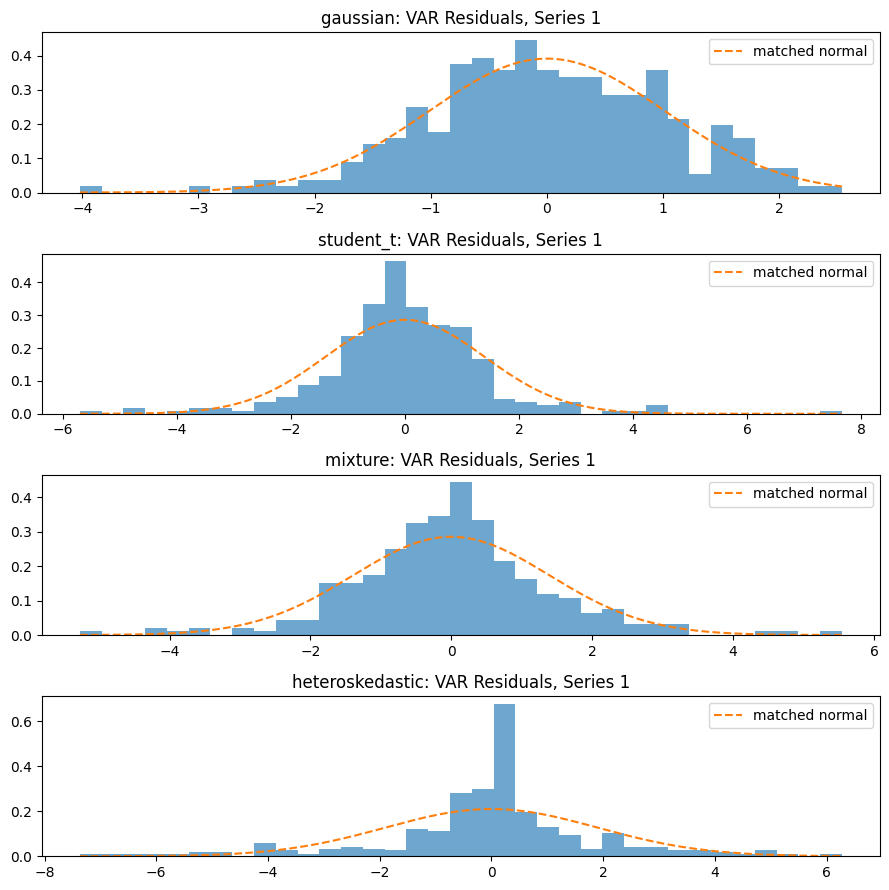

In [4]:
fig, axes = plt.subplots(
    len(residual_store),
    1,
    figsize=(9, 9),
    sharex=False,
)

for ax, (name, residuals) in zip(axes, residual_store.items()):
    x = residuals[:, 0]

    ax.hist(
        x,
        bins=35,
        density=True,
        alpha=0.65,
    )

    grid = np.linspace(x.min(), x.max(), 300)
    normal_pdf = stats.norm.pdf(
        grid,
        loc=x.mean(),
        scale=x.std(ddof=1),
    )

    ax.plot(
        grid,
        normal_pdf,
        linestyle="--",
        label="matched normal",
    )

    ax.set_title(f"{name}: VAR Residuals, Series 1")
    ax.legend()

plt.tight_layout()
plt.show()

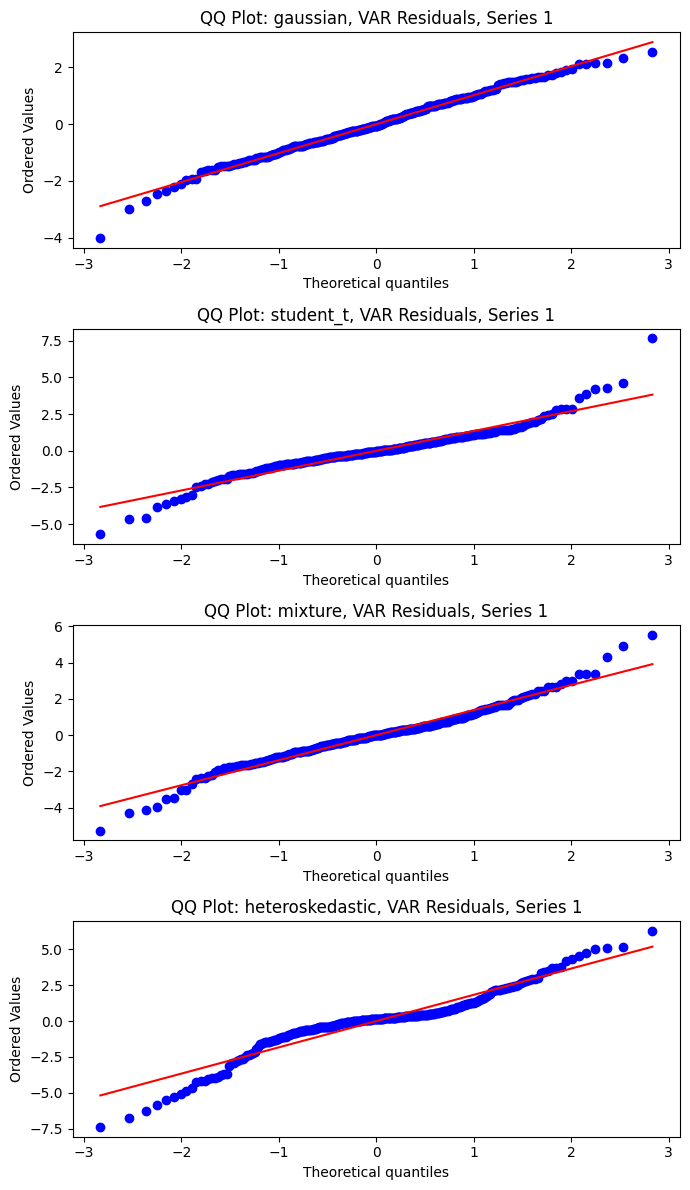

In [5]:
fig, axes = plt.subplots(
    len(residual_store),
    1,
    figsize=(7, 12),
)

for ax, (name, residuals) in zip(axes, residual_store.items()):
    stats.probplot(
        residuals[:, 0],
        dist="norm",
        plot=ax,
    )

    ax.set_title(f"QQ Plot: {name}, VAR Residuals, Series 1")

plt.tight_layout()
plt.show()

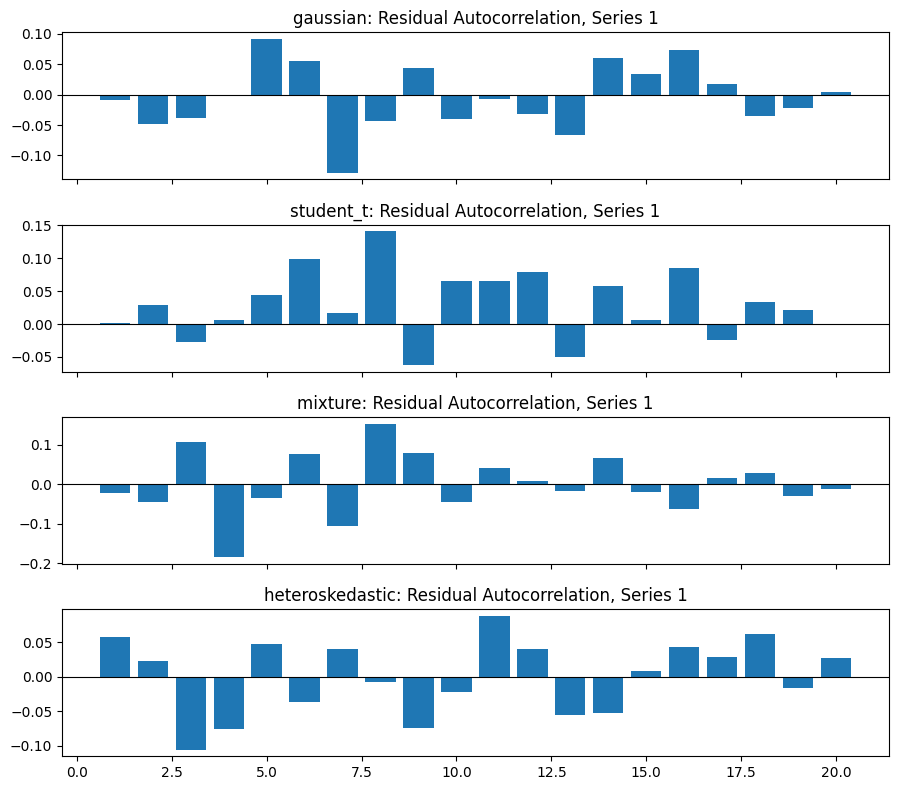

In [6]:
fig, axes = plt.subplots(
    len(residual_store),
    1,
    figsize=(9, 8),
    sharex=True,
)

max_lag = 20

for ax, (name, residuals) in zip(axes, residual_store.items()):
    x = residuals[:, 0]
    acfs = []

    for lag in range(1, max_lag + 1):
        acf = np.corrcoef(x[:-lag], x[lag:])[0, 1]
        acfs.append(acf)

    ax.bar(
        np.arange(1, max_lag + 1),
        acfs,
    )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{name}: Residual Autocorrelation, Series 1")

plt.tight_layout()
plt.show()

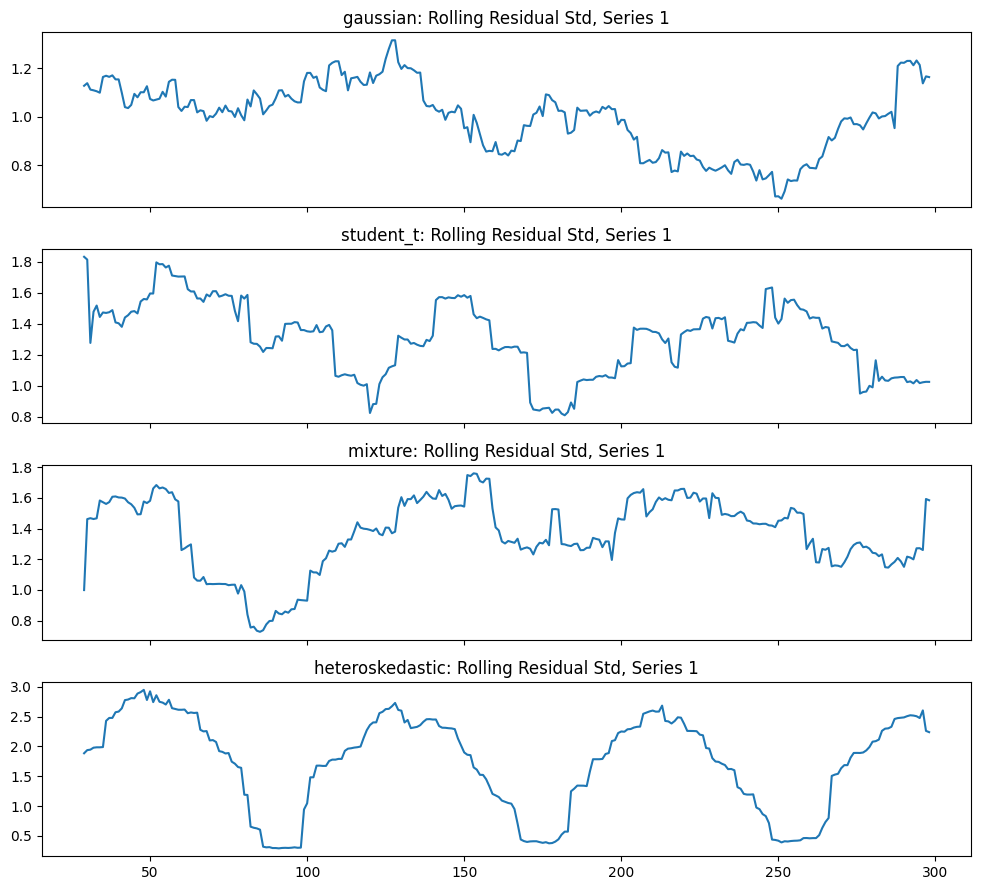

In [7]:
window = 30

fig, axes = plt.subplots(
    len(residual_store),
    1,
    figsize=(10, 9),
    sharex=True,
)

for ax, (name, residuals) in zip(axes, residual_store.items()):
    x = residuals[:, 0]

    rolling_std = pd.Series(x).rolling(window).std()

    ax.plot(rolling_std)
    ax.set_title(f"{name}: Rolling Residual Std, Series 1")

plt.tight_layout()
plt.show()

In [10]:
# save notebook log
run_dir = make_run_dir(
    base_dir=ROOT / "logs" / "experiments",
    run_name="03_residuals",
)

metrics = {
    "notebook": "03_residuals",
    "dgp_names": dgp_names,
    "residual_files_saved": True,
    "diagnostics_saved": True,
}

save_metrics_json(
    metrics,
    run_dir / "residual_diagnostics_config.json",
)

print("Saved logs to:", run_dir)

Saved logs to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/logs/experiments/20260519_140352_03_residuals
